In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [5]:
# Загрузка данных
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


<h2>Модель на необработанных данных</h2>

In [6]:
# Удаление пропусков и категориальных переменных
df_raw = df.dropna().drop(columns=['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'])

# Разделение данных
X = df_raw.drop(columns='survived')
y = df_raw['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Метрика качества
accuracy_raw = accuracy_score(y_test, y_pred)
print(f"Accuracy (необработанные данные): {accuracy_raw:.4f}")

Accuracy (необработанные данные): 0.7568


<h2>Очистка данных</h2>

In [7]:
df_clean = df.drop(columns=['alive', 'class', 'embark_town', 'who'])

In [ ]:
#age: Замена медианой
#deck: Замена новым классом "Unknown"
#embarked: Замена модой ("S")
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
df_clean['deck'].fillna('Unknown', inplace=True)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

In [9]:
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked', 'deck'])

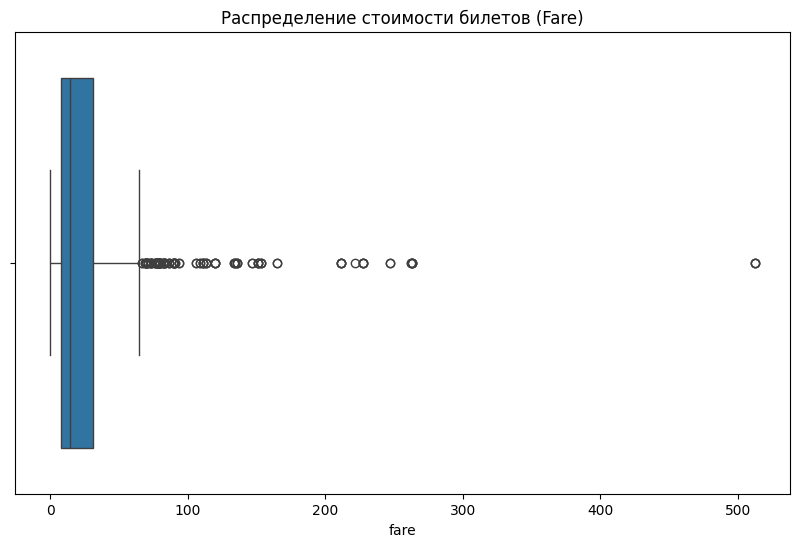

In [10]:
# Визуализация выбросов в 'fare'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_clean['fare'])
plt.title('Распределение стоимости билетов (Fare)')
plt.show()

# Удаление верхних 1% значений
fare_upper_limit = df_clean['fare'].quantile(0.99)
df_clean = df_clean[df_clean['fare'] <= fare_upper_limit]

In [ ]:
#Ghtj,hfpjdfybt ghbpyfrf age
df_clean['age_log'] = np.log1p(df_clean['age'])

In [16]:
#Модель на очищенных данных
X_clean = df_clean.drop(columns='survived')
y_clean = df_clean['survived']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

model.fit(X_train_c, y_train_c)
y_pred_c = model.predict(X_test_c)

accuracy_clean = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy (очищенные данные): {accuracy_clean:.4f}, прирост составил 0,0737")

Accuracy (очищенные данные): 0.8305, прирост составил 0,0737


<p>Выполненные преобразования:</p>

<p>Удалены дублирующие и коррелирующие признаки.</p>

<p>Пропуски заполнены: age (медиана), deck (новый класс), embarked (мода).</p>

<p>Категориальные переменные закодированы one-hot.</p>

<p>Удалены экстремальные выбросы в fare.</p>

<p>Признак age преобразован логарифмированием.</p>

<p>Сравнение метрик:</p>

<p>Необработанные данные: 0.7568%</p>

<p>Очищенные данные: 0.8305%</p>
<p>Улучшение: +0,0737"%</p>

<p>Целесообразность обработки данных:</p>

<p>Качественная очистка данных существенно улучшает метрики моделей.</p>